# 🎯 Pemodelan Machine Learning — Sistem Rekomendasi Karir IT

Notebook ini membangun **sistem rekomendasi karir IT** berbasis *machine learning* menggunakan
dataset bersih & balanced (`dataset_so_smote_balanced_injected.csv`) hasil tahap *data wrangling*.

**Rumusan masalah:** *multi-class classification*. Diberikan profil seorang developer
(skills, tools, databases, lama pengalaman koding, dan tingkat pendidikan), model memprediksi
**Top-N rekomendasi karir** yang paling cocok beserta skor probabilitasnya.

**Alur notebook:**
1. Load & eksplorasi singkat dataset
2. *Feature engineering* (multi-hot encoding untuk kolom multi-nilai + fitur numerik)
3. Train/test split (stratified)
4. Latih & bandingkan **3 model**: Logistic Regression, Random Forest, XGBoost
5. Evaluasi (Accuracy, Macro-F1, **Top-3 Accuracy**, confusion matrix)
6. Pilih model terbaik → bangun fungsi `recommend_career()` (Top-N)
7. Demo & simpan artefak model (`.joblib`)


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Library siap.')

Library siap.


## 2. Load Dataset

In [2]:
df = pd.read_csv('../Data Wrangling/dataset_so_smote_balanced_injected.csv')
print('Shape:', df.shape)
df.head()

Shape: (139079, 6)


,all_skills,tools,databases,years_code,education_level,career_label
0,amazon web services (aws);angular;bash/shell (...,intellij idea;pycharm;sublime text;vim;visual ...,elasticsearch;mariadb;mongodb;postgresql;redis,19.0,2.0,Backend Developer
1,assembly;bash/shell (all shells);cargo;cloudfl...,none,elasticsearch;postgresql;redis;sqlite,35.0,1.0,Backend Developer
2,amazon web services (aws);docker;elixir;erlang...,visual studio code,postgresql,13.0,2.0,Backend Developer
3,amazon web services (aws);apt;asp.net;asp.net ...,nano;notepad++;rider;visual studio;visual stud...,mariadb;microsoft sql server;mysql;sqlite,4.0,2.0,Backend Developer
4,amazon web services (aws);angular;ansible;apt;...,claude code;jupyter notebook/jupyterlab;neovim...,elasticsearch;postgresql;redis,10.0,2.0,Backend Developer


In [3]:
print('Info kolom:')
df.info()
print('\nJumlah nilai kosong per kolom:')
print(df.isna().sum())

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139079 entries, 0 to 139078
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   all_skills       139079 non-null  object 
 1   tools            139079 non-null  object 
 2   databases        139079 non-null  object 
 3   years_code       139079 non-null  float64
 4   education_level  139079 non-null  float64
 5   career_label     139079 non-null  object 
dtypes: float64(2), object(4)
memory usage: 6.4+ MB

Jumlah nilai kosong per kolom:
all_skills         0
tools              0
databases          0
years_code         0
education_level    0
career_label       0
dtype: int64


### Distribusi label karir
Karena dataset sudah di-*balance* dengan SMOTE, jumlah tiap kelas relatif seimbang —
ini penting agar model tidak bias ke kelas mayoritas.

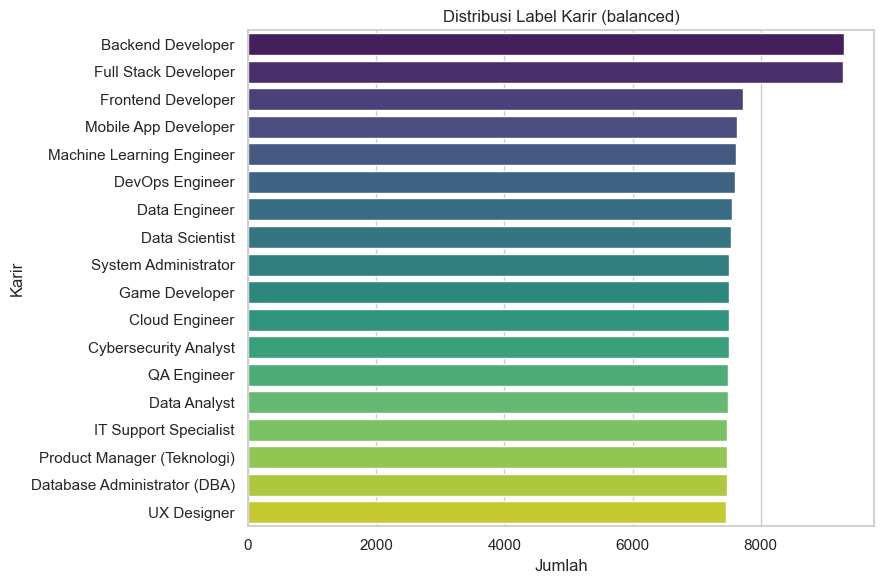

Jumlah kelas: 18


In [4]:
plt.figure(figsize=(9,6))
order = df['career_label'].value_counts().index
sns.countplot(y='career_label', data=df, order=order, palette='viridis')
plt.title('Distribusi Label Karir (balanced)')
plt.xlabel('Jumlah'); plt.ylabel('Karir')
plt.tight_layout(); plt.show()
print('Jumlah kelas:', df['career_label'].nunique())

## 3. Feature Engineering

Kolom `all_skills`, `tools`, dan `databases` berisi **banyak nilai** yang dipisah tanda `;`
(contoh: `python;sql;docker`). Kita ubah menjadi representasi **multi-hot** (1/0 per token)
menggunakan `MultiLabelBinarizer` — satu kolom biner untuk tiap skill/tool/database.

Kolom `years_code` dan `education_level` sudah numerik; `years_code` kita standarisasi.

In [5]:
multi_cols = ['all_skills', 'tools', 'databases']
num_cols   = ['years_code', 'education_level']
TARGET     = 'career_label'

# Pisahkan token tiap kolom multi-nilai
def split_tokens(series):
    return series.fillna('none').str.lower().str.split(';').apply(
        lambda lst: [t.strip() for t in lst if t.strip()])

encoders = {}
feature_blocks = []
feature_names  = []

for col in multi_cols:
    tokens = split_tokens(df[col])
    mlb = MultiLabelBinarizer(sparse_output=False)
    mat = mlb.fit_transform(tokens)
    encoders[col] = mlb
    feature_blocks.append(mat)
    feature_names += [f'{col}={c}' for c in mlb.classes_]
    print(f'{col:12s} -> {mat.shape[1]} fitur biner')

X_multi = np.hstack(feature_blocks)
print('Total fitur multi-hot:', X_multi.shape[1])

all_skills   -> 165 fitur biner


tools        -> 62 fitur biner


databases    -> 31 fitur biner
Total fitur multi-hot: 258


In [6]:
# Fitur numerik
scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols].values)
feature_names += num_cols

# Gabungkan semua fitur
X = np.hstack([X_multi, X_num]).astype(np.float32)
y_raw = df[TARGET].values
print('Matriks fitur final X:', X.shape)
print('Contoh nama fitur:', feature_names[:5], '...', feature_names[-2:])

Matriks fitur final X: (139079, 260)
Contoh nama fitur: ['all_skills=3d modeling', 'all_skills=ada', 'all_skills=amazon web services (aws)', 'all_skills=angular', 'all_skills=angularjs'] ... ['years_code', 'education_level']


In [7]:
# Encode target jadi angka (dibutuhkan XGBoost & top_k_accuracy)
classes = np.sort(df[TARGET].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
y = np.array([class_to_idx[v] for v in y_raw])
print('Jumlah kelas:', len(classes))

Jumlah kelas: 18


## 4. Train / Test Split (stratified)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (111263, 260) | Test: (27816, 260)


## 5. Latih & Bandingkan Model

Tiga algoritma kita bandingkan secara adil pada split yang sama:
- **Logistic Regression** — baseline linear, cepat & interpretable
- **Random Forest** — ensemble pohon, kuat untuk data tabular
- **XGBoost** — gradient boosting, biasanya akurasi tertinggi

Metrik: **Accuracy**, **Macro-F1** (rata-rata F1 semua kelas), dan
**Top-3 Accuracy** (apakah karir sebenarnya ada di 3 rekomendasi teratas — paling relevan
untuk sistem rekomendasi).

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1,
                                              random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                             subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                             n_jobs=-1, random_state=RANDOM_STATE,
                             objective='multi:softprob', num_class=len(classes),
                             eval_metric='mlogloss')
}

results = {}
trained = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    pred  = proba.argmax(axis=1)
    acc   = accuracy_score(y_test, pred)
    f1    = f1_score(y_test, pred, average='macro')
    top3  = top_k_accuracy_score(y_test, proba, k=3, labels=np.arange(len(classes)))
    results[name] = {'Accuracy': acc, 'Macro-F1': f1, 'Top-3 Acc': top3,
                     'Train time (s)': round(time.time()-t0, 1)}
    trained[name] = model
    print(f'{name:22s} | Acc={acc:.4f} | MacroF1={f1:.4f} | Top3={top3:.4f} '
          f'| {results[name]["Train time (s)"]}s')

Logistic Regression    | Acc=0.7700 | MacroF1=0.7762 | Top3=0.9329 | 59.4s


Random Forest          | Acc=0.9740 | MacroF1=0.9777 | Top3=0.9980 | 84.2s


XGBoost                | Acc=0.9697 | MacroF1=0.9736 | Top3=0.9976 | 136.2s


In [10]:
res_df = pd.DataFrame(results).T.sort_values('Top-3 Acc', ascending=False)
res_df

,Accuracy,Macro-F1,Top-3 Acc,Train time (s)
Random Forest,0.974044,0.977739,0.997951,84.2
XGBoost,0.969694,0.973590,0.997591,136.2
Logistic Regression,0.769988,0.776180,0.932880,59.4


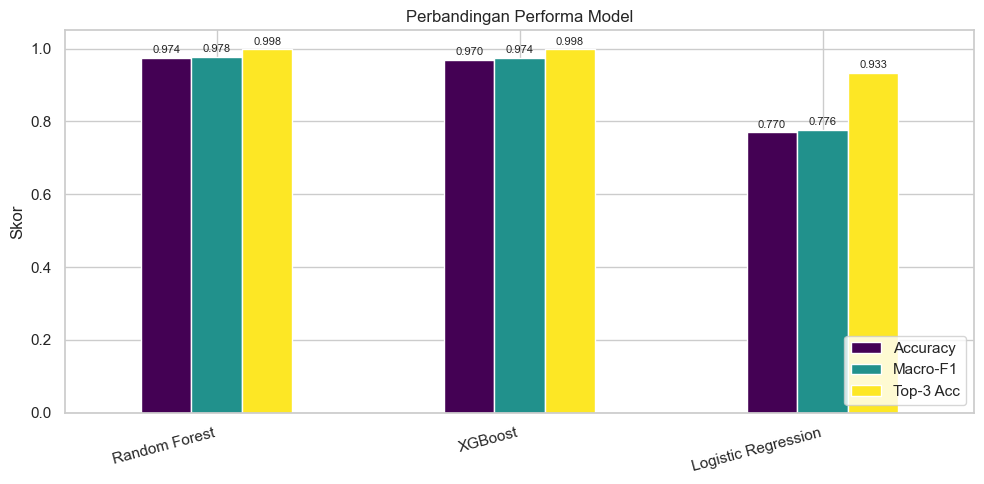

In [11]:
ax = res_df[['Accuracy','Macro-F1','Top-3 Acc']].plot(
        kind='bar', figsize=(10,5), colormap='viridis')
plt.title('Perbandingan Performa Model')
plt.ylabel('Skor'); plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.05); plt.legend(loc='lower right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

## 6. Evaluasi Detail Model Terbaik

In [12]:
best_name = res_df.index[0]
best_model = trained[best_name]
print('Model terbaik:', best_name)

best_pred = best_model.predict(X_test)
print('\nClassification Report:\n')
print(classification_report(y_test, best_pred,
        target_names=[idx_to_class[i] for i in range(len(classes))]))

Model terbaik: Random Forest



Classification Report:

                              precision    recall  f1-score   support

           Backend Developer       0.86      0.80      0.83      1860
              Cloud Engineer       1.00      0.99      0.99      1500
       Cybersecurity Analyst       1.00      1.00      1.00      1499
                Data Analyst       1.00      1.00      1.00      1498
               Data Engineer       1.00      1.00      1.00      1511
              Data Scientist       1.00      1.00      1.00      1506
Database Administrator (DBA)       1.00      1.00      1.00      1493
             DevOps Engineer       0.98      0.98      0.98      1521
          Frontend Developer       0.96      0.99      0.97      1545
        Full Stack Developer       0.81      0.86      0.84      1856
              Game Developer       1.00      1.00      1.00      1501
       IT Support Specialist       1.00      1.00      1.00      1495
   Machine Learning Engineer       1.00      1.00      1.00     

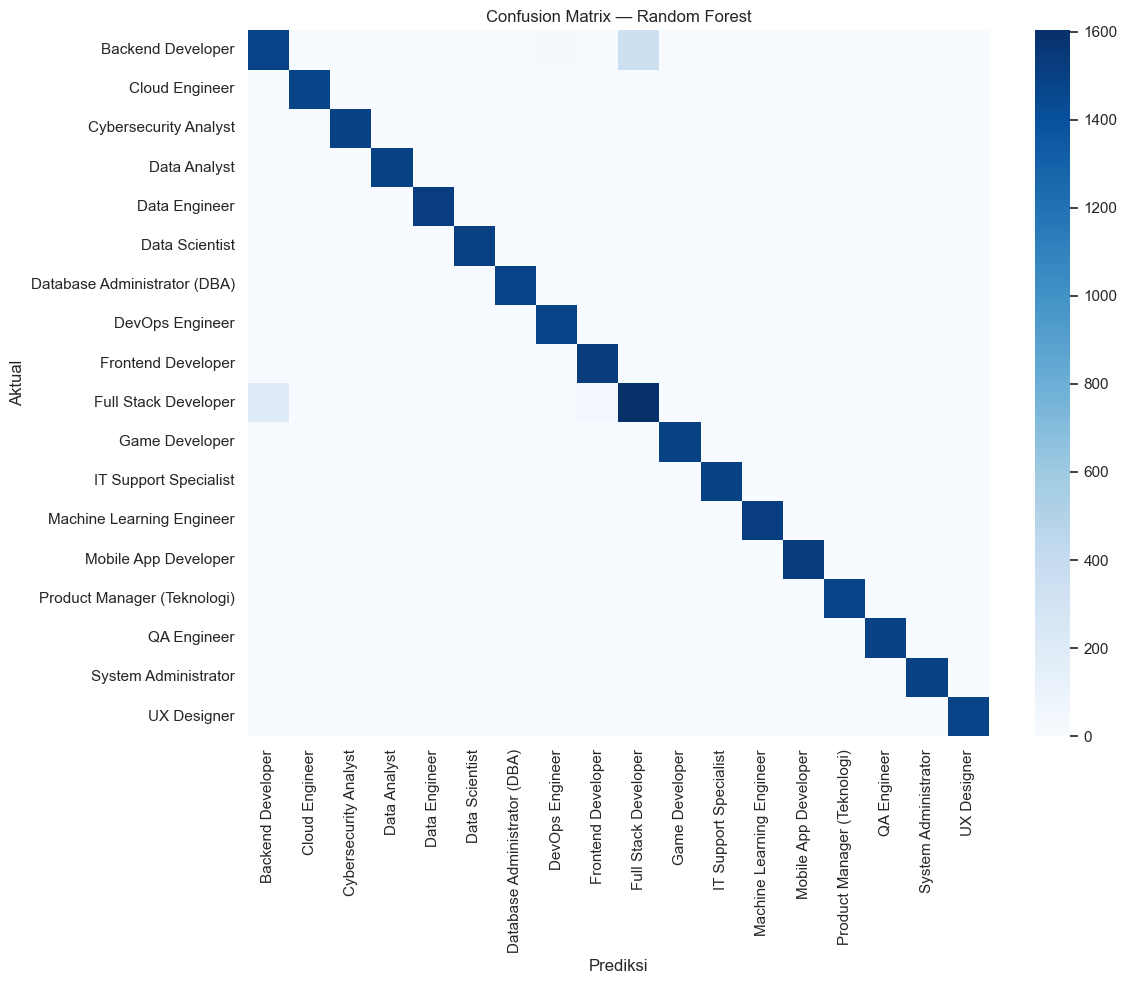

In [13]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(len(classes))],
            yticklabels=[idx_to_class[i] for i in range(len(classes))])
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout(); plt.show()

### Fitur paling berpengaruh
Skill/tool yang paling menentukan keputusan model (jika model mendukung *feature importances*).

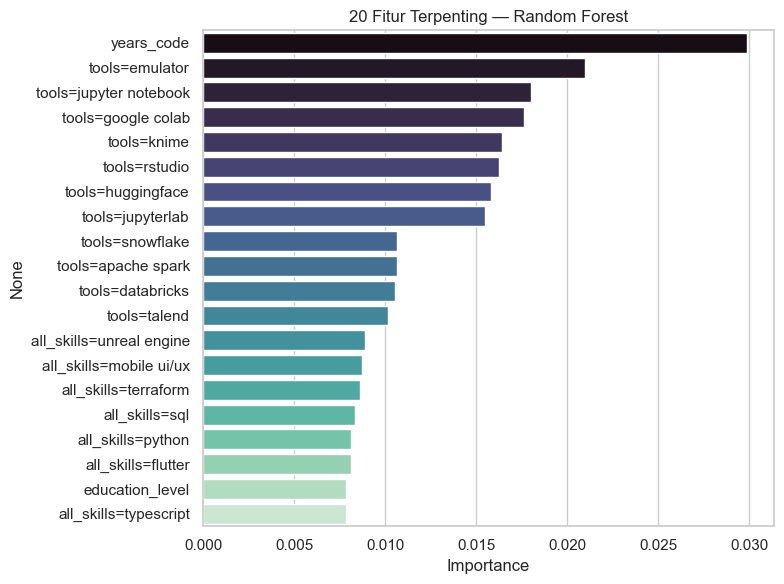

In [14]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_names)
    top_imp = imp.sort_values(ascending=False).head(20)
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_imp.values, y=top_imp.index, palette='mako')
    plt.title(f'20 Fitur Terpenting — {best_name}')
    plt.xlabel('Importance'); plt.tight_layout(); plt.show()
else:
    print(f'{best_name} tidak menyediakan feature_importances_.')

## 7. Sistem Rekomendasi — Fungsi `recommend_career()`

Fungsi ini menerima profil baru (skills/tools/databases + pengalaman + pendidikan),
mengubahnya ke representasi fitur yang sama, lalu mengembalikan **Top-N karir**
beserta skor kecocokan (probabilitas).

In [15]:
def _vectorize_profile(skills, tools, databases, years_code, education_level):
    """Ubah profil mentah menjadi vektor fitur sesuai encoder yang sudah di-fit."""
    raw = {'all_skills': skills, 'tools': tools, 'databases': databases}
    blocks = []
    for col in multi_cols:
        toks = [t.strip().lower() for t in (raw[col] or []) if t.strip()]
        blocks.append(encoders[col].transform([toks]))
    x_multi = np.hstack(blocks)
    x_num = scaler.transform([[years_code, education_level]])
    return np.hstack([x_multi, x_num]).astype(np.float32)


def recommend_career(skills, tools=None, databases=None, years_code=5,
                     education_level=2, top_n=3, model=None):
    """Rekomendasikan Top-N karir IT untuk sebuah profil.

    Parameters
    ----------
    skills : list[str]      contoh ['python','sql','docker']
    tools : list[str]       contoh ['visual studio code']
    databases : list[str]   contoh ['postgresql']
    years_code : float      lama pengalaman koding (tahun)
    education_level : int   level pendidikan (skala dataset: 0-6)
    top_n : int             jumlah rekomendasi
    """
    model = model or best_model
    x = _vectorize_profile(skills, tools or [], databases or [],
                           years_code, education_level)
    proba = model.predict_proba(x)[0]
    top_idx = proba.argsort()[::-1][:top_n]
    return [{'rank': r+1,
             'career': idx_to_class[i],
             'score': round(float(proba[i]), 4)}
            for r, i in enumerate(top_idx)]

### Demo rekomendasi

In [16]:
# Contoh 1: profil cenderung Data / ML
profil_ds = recommend_career(
    skills=['python','sql','r','pandas','tensorflow','pytorch'],
    tools=['jupyter notebook','pycharm'],
    databases=['postgresql','mongodb'],
    years_code=4, education_level=3, top_n=3)
print('Profil Data/ML ->')
for r in profil_ds: print('  ', r)

Profil Data/ML ->
   {'rank': 1, 'career': 'Machine Learning Engineer', 'score': 0.91}
   {'rank': 2, 'career': 'Data Scientist', 'score': 0.06}
   {'rank': 3, 'career': 'Backend Developer', 'score': 0.02}


In [17]:
# Contoh 2: profil cenderung Frontend / Web
profil_fe = recommend_career(
    skills=['javascript','typescript','react','html/css','node.js'],
    tools=['visual studio code','webstorm'],
    databases=['postgresql'],
    years_code=3, education_level=2, top_n=3)
print('Profil Web ->')
for r in profil_fe: print('  ', r)

Profil Web ->
   {'rank': 1, 'career': 'Frontend Developer', 'score': 0.75}
   {'rank': 2, 'career': 'Full Stack Developer', 'score': 0.215}
   {'rank': 3, 'career': 'Backend Developer', 'score': 0.02}


In [18]:
# Contoh 3: profil cenderung DevOps / Cloud
profil_devops = recommend_career(
    skills=['bash/shell (all shells)','docker','kubernetes','python','terraform'],
    tools=['vim'],
    databases=['redis','postgresql'],
    years_code=7, education_level=2, top_n=3)
print('Profil DevOps/Cloud ->')
for r in profil_devops: print('  ', r)

Profil DevOps/Cloud ->
   {'rank': 1, 'career': 'Backend Developer', 'score': 0.45}
   {'rank': 2, 'career': 'DevOps Engineer', 'score': 0.395}
   {'rank': 3, 'career': 'Cloud Engineer', 'score': 0.065}


## 8. Simpan Artefak Model

Simpan model terbaik + semua encoder agar bisa dipakai ulang (mis. di aplikasi web/API)
tanpa melatih ulang.

In [19]:
artifact = {
    'model': best_model,
    'model_name': best_name,
    'mlb_encoders': encoders,
    'scaler': scaler,
    'multi_cols': multi_cols,
    'num_cols': num_cols,
    'feature_names': feature_names,
    'idx_to_class': idx_to_class,
    'class_to_idx': class_to_idx,
}
joblib.dump(artifact, '../deployment/career_recommender_model.joblib')
print('Artefak disimpan -> ../deployment/career_recommender_model.joblib')
print('Model terbaik:', best_name)

Artefak disimpan -> career_recommender_model.joblib
Model terbaik: Random Forest


---
### ✅ Ringkasan
- Dataset bersih & balanced diubah ke **multi-hot encoding** (skills/tools/databases) + fitur numerik.
- Tiga model dibandingkan; **model terbaik dipilih berdasarkan Top-3 Accuracy** (paling relevan untuk rekomendasi).
- Tersedia fungsi `recommend_career()` yang mengembalikan **Top-N karir + skor**.
- Artefak model disimpan (`career_recommender_model.joblib`) untuk integrasi ke aplikasi.

**Cara memakai model tersimpan di proyek lain:**
```python
import joblib, numpy as np
art = joblib.load('career_recommender_model.joblib')
# ... gunakan art['model'], art['mlb_encoders'], art['scaler'] dengan logika _vectorize_profile
```
